In [9]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Make project root importable so that "src" can be found
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    REGION,
    LOW_PRICE_THRESHOLD,
    ROLLING_WINDOW_MONTHS,
    MIN_HISTORY_MONTHS,
    STALE_RETURN_THRESHOLD,
)
from src.paths import get_project_paths, ensure_project_directories
from src.loaders import load_raw_datasets
from src.cleaning import (
    prepare_price_data,
    prepare_market_caps_data,
    prepare_carbon_data,
    apply_low_price_filter,
    compute_returns,
    apply_delisting_returns,
)
from src.universe import build_universe_by_year
from src.optimization import compute_mv_weights_by_year
from src.backtest import run_mv_backtest
from src.benchmark import run_vw_backtest
from src.reporting import (
    build_performance_table,
    compute_cumulative_series,
    plot_cumulative_performance,
    export_part1_outputs,
    fill_part1_excel_template,
)

In [2]:
paths = get_project_paths()
ensure_project_directories(paths)

BASE_DIR = paths["BASE_DIR"]
DATA_RAW = paths["DATA_RAW"]
DATA_PROCESSED = paths["DATA_PROCESSED"]
OUTPUTS = paths["OUTPUTS"]
TABLES_DIR = paths["TABLES_DIR"]
FIGURES_DIR = paths["FIGURES_DIR"]
INTERMEDIATE_DIR = paths["INTERMEDIATE_DIR"]

static, prices_raw, market_caps_raw, carbon_raw = load_raw_datasets(DATA_RAW)

print("Project root detected at:", BASE_DIR)
print("Static shape:", static.shape)
print("Prices raw shape:", prices_raw.shape)
print("Market caps raw shape:", market_caps_raw.shape)
print("Carbon raw shape:", carbon_raw.shape)

Project root detected at: /workspaces/SAAM-Project-Part1
Static shape: (2545, 4)
Prices raw shape: (2609, 316)
Market caps raw shape: (2609, 316)
Carbon raw shape: (2609, 29)


In [3]:
# Regional universe
em_firms = static[static["Region"] == REGION].copy()
em_isins = em_firms["ISIN"].tolist()

# Prepare core datasets
price_data = prepare_price_data(prices_raw, em_isins)
price_data = apply_low_price_filter(price_data, LOW_PRICE_THRESHOLD)

market_caps_data = prepare_market_caps_data(market_caps_raw, em_isins)
carbon_data = prepare_carbon_data(carbon_raw, em_isins)

# Compute monthly returns and apply delisting treatment
returns_matrix = compute_returns(price_data)
returns_matrix = apply_delisting_returns(price_data, returns_matrix)

print("Number of firms in regional universe:", len(em_isins))
print("Price data shape:", price_data.shape)
print("Market caps data shape:", market_caps_data.shape)
print("Carbon data shape:", carbon_data.shape)
print("Returns matrix shape:", returns_matrix.shape)
print("Returns exactly -100%:", (returns_matrix.stack() == -1).sum())

Number of firms in regional universe: 702
Price data shape: (702, 314)
Market caps data shape: (702, 314)
Carbon data shape: (702, 27)
Returns matrix shape: (702, 314)
Returns exactly -100%: 62


In [4]:
rebalance_years = list(range(2014, 2026))

universe_by_year = build_universe_by_year(
    returns_matrix=returns_matrix,
    price_data=price_data,
    carbon_data=carbon_data,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
    min_history_months=MIN_HISTORY_MONTHS,
    stale_return_threshold=STALE_RETURN_THRESHOLD,
)

mv_weights_by_year = compute_mv_weights_by_year(
    returns_matrix=returns_matrix,
    universe_by_year=universe_by_year,
    rebalance_years=rebalance_years,
    rolling_window_months=ROLLING_WINDOW_MONTHS,
)

print("Universe sizes:")
for year in rebalance_years:
    print(f"{year}: {len(universe_by_year[year])} firms")

print("\n2014 MV portfolio:")
print("Number of firms in 2014 MV portfolio:", len(mv_weights_by_year[2014]))
print("Sum of weights in 2014:", mv_weights_by_year[2014].sum())
mv_weights_by_year[2014].head()

Universe sizes:
2014: 254 firms
2015: 278 firms
2016: 309 firms
2017: 345 firms
2018: 389 firms
2019: 424 firms
2020: 472 firms
2021: 511 firms
2022: 546 firms
2023: 573 firms
2024: 584 firms
2025: 568 firms

2014 MV portfolio:
Number of firms in 2014 MV portfolio: 254
Sum of weights in 2014: 1.0


ISIN
BRBBASACNOR3    2.358505e-18
BRBBDCACNPR8    0.000000e+00
BRBRFSACNOR8    0.000000e+00
BRBRKMACNPA4    0.000000e+00
BRCESPACNPB4    0.000000e+00
dtype: float64

In [5]:
mv_returns_by_year, mv_returns_oos = run_mv_backtest(
    returns_matrix=returns_matrix,
    mv_weights_by_year=mv_weights_by_year,
    rebalance_years=rebalance_years,
)

vw_returns_by_year, vw_returns_oos = run_vw_backtest(
    returns_matrix=returns_matrix,
    market_caps_data=market_caps_data,
    universe_by_year=universe_by_year,
    rebalance_years=rebalance_years,
)

print("MV OOS shape:", mv_returns_oos.shape)
print("MV first date:", mv_returns_oos.index.min())
print("MV last date:", mv_returns_oos.index.max())
print("MV total cumulative return:", (1 + mv_returns_oos).prod() - 1)

print("\nVW OOS shape:", vw_returns_oos.shape)
print("VW first date:", vw_returns_oos.index.min())
print("VW last date:", vw_returns_oos.index.max())
print("VW total cumulative return:", (1 + vw_returns_oos).prod() - 1)

MV OOS shape: (144,)
MV first date: 2014-01-31 00:00:00
MV last date: 2025-12-31 00:00:00
MV total cumulative return: 1.3956355033756265

VW OOS shape: (144,)
VW first date: 2014-01-31 00:00:00
VW last date: 2025-12-31 00:00:00
VW total cumulative return: 1.2918006638928738


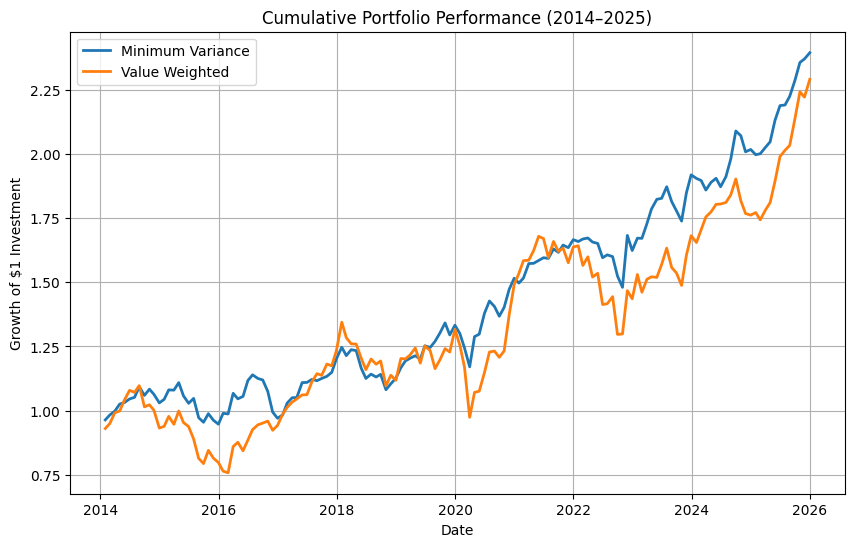

Performance table:


,Portfolio,Annualized Return,Annualized Volatility,Sharpe Ratio,Minimum Monthly Return,Maximum Monthly Return,Total Cumulative Return
0,Minimum Variance,0.078752,0.108075,0.728680,-0.074699,0.136727,1.395636
1,Value Weighted,0.081563,0.156772,0.520267,-0.167606,0.134429,1.291801



Figure saved at: /workspaces/SAAM-Project-Part1/outputs/figures/cumulative_portfolio_performance.png
Figure exists: True

Exported files:
mv_returns_oos -> /workspaces/SAAM-Project-Part1/outputs/tables/mv_returns_oos.csv | exists: True
vw_returns_oos -> /workspaces/SAAM-Project-Part1/outputs/tables/vw_returns_oos.csv | exists: True
performance_summary -> /workspaces/SAAM-Project-Part1/outputs/tables/portfolio_performance_summary.csv | exists: True


In [6]:
performance = build_performance_table(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
)

mv_cumulative, vw_cumulative = compute_cumulative_series(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
)

figure_path = plot_cumulative_performance(
    mv_cumulative=mv_cumulative,
    vw_cumulative=vw_cumulative,
    figures_dir=FIGURES_DIR,
    show_plot=True,
)

exported_paths = export_part1_outputs(
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
    performance=performance,
    tables_dir=TABLES_DIR,
)

print("Performance table:")
display(performance)

print("\nFigure saved at:", figure_path)
print("Figure exists:", figure_path.exists())

print("\nExported files:")
for name, path in exported_paths.items():
    print(name, "->", path, "| exists:", path.exists())

In [10]:
filled_template_path = fill_part1_excel_template(
    templates_dir=paths["TEMPLATES_DIR"],
    excel_dir=paths["EXCEL_DIR"],
    figures_dir=paths["FIGURES_DIR"],
    mv_returns_oos=mv_returns_oos,
    vw_returns_oos=vw_returns_oos,
)

print("Filled template saved at:")
print(filled_template_path)
print("File exists:", filled_template_path.exists())

Filled template saved at:
/workspaces/SAAM-Project-Part1/outputs/excel/Part_I_template_filled.xlsx
File exists: True
